# Importing libraries

In [2]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import matplotlib.dates as mdates
from datetime import datetime,timedelta
from pathlib import Path
from typing import Dict, Tuple
#from oceanicospy.observations import AWAC,AQUAlogger,WeatherStation,ResistiveSensor
#from oceanicospy.analysis import spectral,temporal

### Class to read SWAN output (consultar si se debería incluir a la librería)

In [3]:
class SwanOutputReader:
 
    # Fixed schema for SalidasSWAN.out
    _COLS = ['Time','Xp','Yp','Depth','X-Windv','Y-Windv','Hsig','TPsmoo','Tm01','Tm02','Dir']
    _DTYPE = {'Time': str, 'Xp': float, 'Yp': float, 'Depth': float,
              'X-Windv': float, 'Y-Windv': float, 'Hsig': float,
              'TPsmoo': float, 'Tm01': float, 'Tm02': float, 'Dir': float}

    def __init__(self, hs_col: str = "Hsig", tp_col: str = "TPsmoo",
                 dir_col: str = "Dir", n_points: int = 2):
        """
        Parameters
        ----------
        hs_col : str
            Column name for significant wave height.
        tp_col : str
            Column name for peak period.
        dir_col : str
            Column name for mean wave direction.
        n_points : int
            Number of interleaved points in the file.
        """
        self.hs_col = hs_col
        self.tp_col = tp_col
        self.dir_col = dir_col
        self.n_points = int(n_points)

    def _read_domain_df(self, file_path: Path) -> pd.DataFrame:

        df = pd.read_csv(
            file_path, skiprows=7, sep=r"\s+", index_col=0,
            names=self._COLS, dtype=self._DTYPE, engine="python"
        )
        # Parse index to datetime, drop invalid, ensure tz-naive, sort
        idx = pd.to_datetime(df.index, format='%Y%m%d.%H%M%S', errors='coerce')
        mask = ~idx.isna()
        df = df.loc[mask].copy()
        df.index = idx[mask].tz_localize(None)
        return df.sort_index()

    def _build_stride_dict(self, series: pd.Series) -> Dict[int, pd.Series]:
        """
        Split an interleaved series into n_points sub-series by striding.
        """
        return {i + 1: series.iloc[i::self.n_points] for i in range(self.n_points)}

    def load_domain(self, domain_dir: Path, start: pd.Timestamp, end: pd.Timestamp
                    ) -> Tuple[Dict[str, Dict[int, pd.Series]], pd.DatetimeIndex]:
        """
        Load one domain, crop by time, and return per-variable dictionaries.

        Returns
        -------
        time_series_sims : dict
            {'hs': {point: Series}, 'tp': {point: Series}, 'dir': {point: Series}}
        time_index : pd.DatetimeIndex
            Common time vector taken from point 1 of 'hs'
        """
        df = self._read_domain_df(domain_dir / "SalidasSWAN.out")
        df_crop = df.loc[start:end]

        out = {}
        if self.hs_col in df_crop:
            out["hs"] = self._build_stride_dict(df_crop[self.hs_col])
        if self.tp_col in df_crop:
            out["tp"] = self._build_stride_dict(df_crop[self.tp_col])
        if self.dir_col and (self.dir_col in df_crop):
            out["dir"] = self._build_stride_dict(df_crop[self.dir_col])

        # Choose a robust time vector (prefer hs, else tp, else dir)
        for key in ("hs", "tp", "dir"):
            if key in out and 1 in out[key]:
                time_index = out[key][1].index
                break
        else:
            # No expected columns found
            raise ValueError("None of the requested columns were found in the cropped DataFrame.")

        return out, time_index

# SP2 buoy vs SWAN (ERA5-Forced)

## Reading SWAN data

In [12]:
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")
path_case = Path("/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_ERA5/run")

reader = SwanOutputReader(hs_col="Hsig", tp_col="TPsmoo", dir_col="Dir", n_points=2)

time_series_sims1, time1 = reader.load_domain(path_case / "domain_01", start_datetime, end_datetime)
time_series_sims2, time2 = reader.load_domain(path_case / "domain_02", start_datetime, end_datetime)
time_series_sims3, time3 = reader.load_domain(path_case / "domain_03", start_datetime, end_datetime)

dict_data_hs1 = time_series_sims1['hs']
dict_data_tp1 = time_series_sims1['tp']
dict_data_dir1 = time_series_sims1['dir']

dict_data_hs2 = time_series_sims2['hs']
dict_data_tp2 = time_series_sims2['tp']
dict_data_dir2 = time_series_sims2['dir']

dict_data_hs3 = time_series_sims3['hs']
dict_data_tp3 = time_series_sims3['tp']
dict_data_dir3 = time_series_sims3['dir']

## Reading field data

In [13]:
file_path = r'/scratchsan/medellin/lroserom/working_folder/data/processed/may2023/Out_Reef/buoy_outreef_may2023.csv'


# Read CSV with the first row as column headers
df_SP2_buoy = pd.read_csv(file_path, header=0)
df_SP2_buoy["date"] = pd.to_datetime(df_SP2_buoy["date"])
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")


df_SP2_buoy = df_SP2_buoy.loc[
    (df_SP2_buoy["date"] >= start_datetime) &
    (df_SP2_buoy["date"] <= end_datetime)
]

df_SP2_buoy

,date,Hs[m],Tp[s],Dir[°]
260,2023-05-12 08:00:00,1.76,5.84,56.566
261,2023-05-12 09:00:00,1.84,5.82,59.371
262,2023-05-12 10:00:00,2.83,9.20,65.154
263,2023-05-12 11:00:00,1.94,5.92,64.186
264,2023-05-12 12:00:00,1.86,5.46,66.251
...,...,...,...,...
670,2023-05-30 04:00:00,0.81,5.30,80.441
671,2023-05-30 05:00:00,0.82,5.30,82.552
672,2023-05-30 06:00:00,0.78,5.36,82.811
673,2023-05-30 07:00:00,0.81,5.60,81.111


## Plot

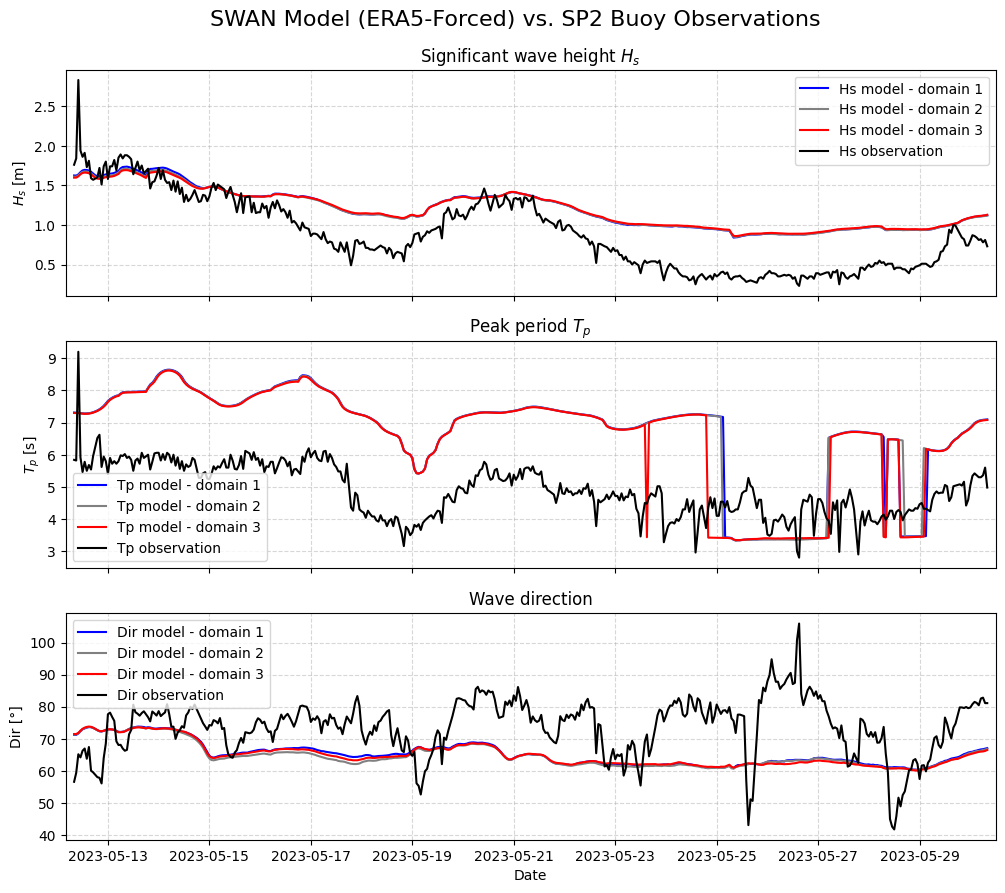

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("SWAN Model (ERA5-Forced) vs. SP2 Buoy Observations", fontsize=16, y=0.94)

# Definir los datos por variable
variables = [
    ('Hs', r'$H_{s}$ [m]', 'Significant wave height $H_{s}$', 'Hs[m]', dict_data_hs1, dict_data_hs2, dict_data_hs3),
    ('Tp', r'$T_{p}$ [s]', 'Peak period $T_{p}$', 'Tp[s]', dict_data_tp1, dict_data_tp2, dict_data_tp3),
    ('Dir', r'Dir [°]', 'Wave direction', 'Dir[°]', dict_data_dir1, dict_data_dir2, dict_data_dir3)
]

times = [time1, time2, time3]
colors = ['blue', 'grey', 'r']
labels = ['model - domain 1', 'model - domain 2', 'model - domain 3']
start_date = datetime(2023,5,12,4,0,0)
end_date = datetime(2023,5,30,12,0,0) - timedelta(minutes=1)

for ax, (varname, ylabel, title, obs_col, d1, d2, d3) in zip(axes, variables):
    for time, color, label, data in zip(times, colors, labels, [d1, d2, d3]):
        ax.plot(time, data[1], color=color, label=f'{varname} {label}')
    
    ax.plot(df_SP2_buoy['date'], df_SP2_buoy[obs_col], color='k', label=f'{varname} observation')
    ax.set(title=title, ylabel=ylabel, xlim=(start_date, end_date))
    ax.legend()
    ax.grid(alpha=0.5, ls='--')

axes[-1].set_xlabel('Date')
plt.show()


# SP1 buoy vs SWAN (ERA5-Forced)

## Reading SWAN data

In [15]:
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")
path_case = Path("/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_ERA5/run")

reader = SwanOutputReader(hs_col="Hsig", tp_col="TPsmoo", dir_col="Dir", n_points=2)

time_series_sims1, time1 = reader.load_domain(path_case / "domain_01", start_datetime, end_datetime)
time_series_sims2, time2 = reader.load_domain(path_case / "domain_02", start_datetime, end_datetime)
time_series_sims3, time3 = reader.load_domain(path_case / "domain_03", start_datetime, end_datetime)

dict_data_hs1 = time_series_sims1['hs']
dict_data_tp1 = time_series_sims1['tp']
dict_data_dir1 = time_series_sims1['dir']

dict_data_hs2 = time_series_sims2['hs']
dict_data_tp2 = time_series_sims2['tp']
dict_data_dir2 = time_series_sims2['dir']

dict_data_hs3 = time_series_sims3['hs']
dict_data_tp3 = time_series_sims3['tp']
dict_data_dir3 = time_series_sims3['dir']

## Reading field data

In [16]:
file_path = r'/scratchsan/medellin/lroserom/working_folder/data/processed/may2023/Lagoon/buoy_lagoon_may2023.csv'


# Read CSV with the first row as column headers
df_SP1_buoy = pd.read_csv(file_path, header=0)
df_SP1_buoy["date"] = pd.to_datetime(df_SP1_buoy["date"])
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")


df_SP1_buoy = df_SP1_buoy.loc[
    (df_SP1_buoy["date"] >= start_datetime) &
    (df_SP1_buoy["date"] <= end_datetime)
]

df_SP1_buoy

,date,Hs[m],Tp[s],Dir[°]
136,2023-05-12 09:00:00,0.245,5.69,179.2245
137,2023-05-12 11:00:00,0.235,6.30,190.1150
138,2023-05-12 13:00:00,0.195,5.75,258.3210
139,2023-05-12 15:00:00,0.210,4.75,205.1780
140,2023-05-12 17:00:00,0.230,4.71,267.3820
...,...,...,...,...
346,2023-05-29 23:00:00,0.145,3.65,340.2195
347,2023-05-30 01:00:00,0.145,3.93,333.2355
348,2023-05-30 03:00:00,0.125,4.17,328.6600
349,2023-05-30 05:00:00,0.120,4.57,309.2155


# Plot

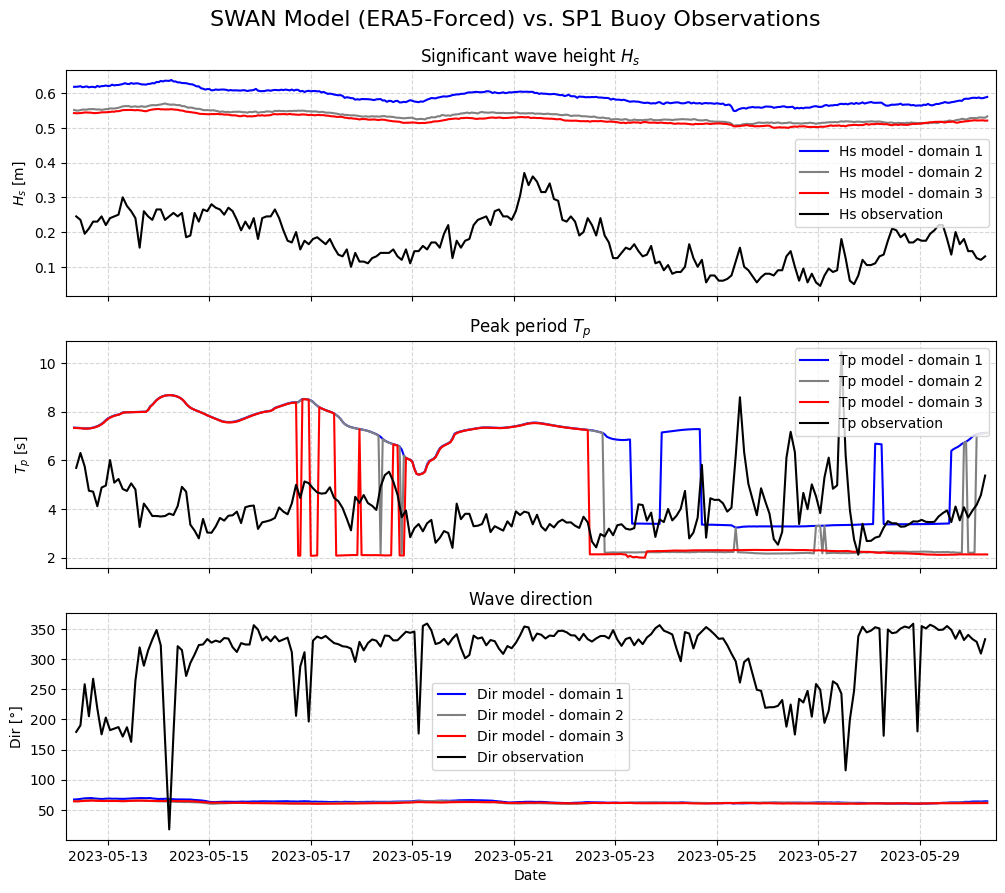

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("SWAN Model (ERA5-Forced) vs. SP1 Buoy Observations", fontsize=16, y=0.94)

# Definir los datos por variable
variables = [
    ('Hs', r'$H_{s}$ [m]', 'Significant wave height $H_{s}$', 'Hs[m]', dict_data_hs1, dict_data_hs2, dict_data_hs3),
    ('Tp', r'$T_{p}$ [s]', 'Peak period $T_{p}$', 'Tp[s]', dict_data_tp1, dict_data_tp2, dict_data_tp3),
    ('Dir', r'Dir [°]', 'Wave direction', 'Dir[°]', dict_data_dir1, dict_data_dir2, dict_data_dir3)
]

times = [time1, time2, time3]
colors = ['blue', 'grey', 'r']
labels = ['model - domain 1', 'model - domain 2', 'model - domain 3']
start_date = datetime(2023,5,12,4,0,0)
end_date = datetime(2023,5,30,12,0,0) - timedelta(minutes=1)

for ax, (varname, ylabel, title, obs_col, d1, d2, d3) in zip(axes, variables):
    for time, color, label, data in zip(times, colors, labels, [d1, d2, d3]):
        ax.plot(time, data[2], color=color, label=f'{varname} {label}')
    
    ax.plot(df_SP1_buoy['date'], df_SP1_buoy[obs_col], color='k', label=f'{varname} observation')
    ax.set(title=title, ylabel=ylabel, xlim=(start_date, end_date))
    ax.legend()
    ax.grid(alpha=0.5, ls='--')

axes[-1].set_xlabel('Date')
plt.show()

# SP2 buoy vs SWAN (CMDS-Forced)

## Reading SWAN data

In [18]:
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")
path_case = Path("/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_CMDS/run")

reader = SwanOutputReader(hs_col="Hsig", tp_col="TPsmoo", dir_col="Dir", n_points=2)

time_series_sims1, time1 = reader.load_domain(path_case / "domain_01", start_datetime, end_datetime)
time_series_sims2, time2 = reader.load_domain(path_case / "domain_02", start_datetime, end_datetime)
time_series_sims3, time3 = reader.load_domain(path_case / "domain_03", start_datetime, end_datetime)

dict_data_hs1 = time_series_sims1['hs']
dict_data_tp1 = time_series_sims1['tp']
dict_data_dir1 = time_series_sims1['dir']

dict_data_hs2 = time_series_sims2['hs']
dict_data_tp2 = time_series_sims2['tp']
dict_data_dir2 = time_series_sims2['dir']

dict_data_hs3 = time_series_sims3['hs']
dict_data_tp3 = time_series_sims3['tp']
dict_data_dir3 = time_series_sims3['dir']

## Reading field data

In [19]:
file_path = r'/scratchsan/medellin/lroserom/working_folder/data/processed/may2023/Out_Reef/buoy_outreef_may2023.csv'


# Read CSV with the first row as column headers
df_SP2_buoy = pd.read_csv(file_path, header=0)
df_SP2_buoy["date"] = pd.to_datetime(df_SP2_buoy["date"])
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")


df_SP2_buoy = df_SP2_buoy.loc[
    (df_SP2_buoy["date"] >= start_datetime) &
    (df_SP2_buoy["date"] <= end_datetime)
]

df_SP2_buoy

,date,Hs[m],Tp[s],Dir[°]
260,2023-05-12 08:00:00,1.76,5.84,56.566
261,2023-05-12 09:00:00,1.84,5.82,59.371
262,2023-05-12 10:00:00,2.83,9.20,65.154
263,2023-05-12 11:00:00,1.94,5.92,64.186
264,2023-05-12 12:00:00,1.86,5.46,66.251
...,...,...,...,...
670,2023-05-30 04:00:00,0.81,5.30,80.441
671,2023-05-30 05:00:00,0.82,5.30,82.552
672,2023-05-30 06:00:00,0.78,5.36,82.811
673,2023-05-30 07:00:00,0.81,5.60,81.111


## Plot

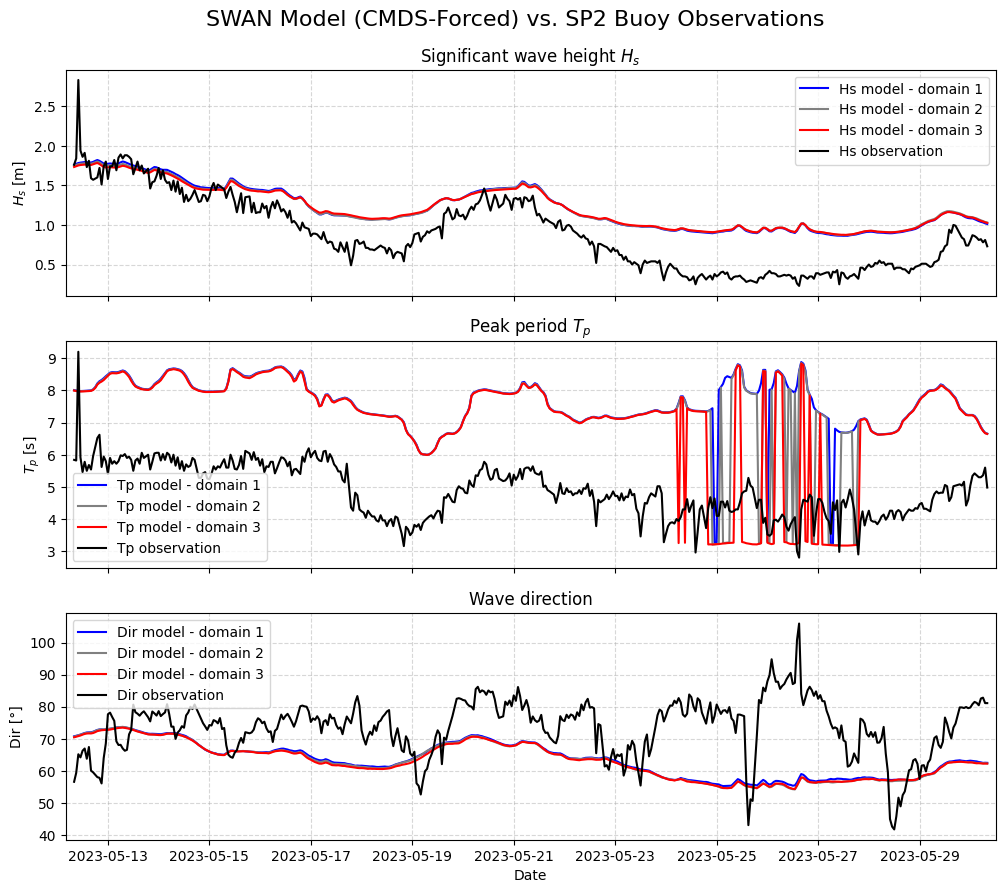

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("SWAN Model (CMDS-Forced) vs. SP2 Buoy Observations", fontsize=16, y=0.94)

# Definir los datos por variable
variables = [
    ('Hs', r'$H_{s}$ [m]', 'Significant wave height $H_{s}$', 'Hs[m]', dict_data_hs1, dict_data_hs2, dict_data_hs3),
    ('Tp', r'$T_{p}$ [s]', 'Peak period $T_{p}$', 'Tp[s]', dict_data_tp1, dict_data_tp2, dict_data_tp3),
    ('Dir', r'Dir [°]', 'Wave direction', 'Dir[°]', dict_data_dir1, dict_data_dir2, dict_data_dir3)
]

times = [time1, time2, time3]
colors = ['blue', 'grey', 'r']
labels = ['model - domain 1', 'model - domain 2', 'model - domain 3']
start_date = datetime(2023,5,12,4,0,0)
end_date = datetime(2023,5,30,12,0,0) - timedelta(minutes=1)

for ax, (varname, ylabel, title, obs_col, d1, d2, d3) in zip(axes, variables):
    for time, color, label, data in zip(times, colors, labels, [d1, d2, d3]):
        ax.plot(time, data[1], color=color, label=f'{varname} {label}')
    
    ax.plot(df_SP2_buoy['date'], df_SP2_buoy[obs_col], color='k', label=f'{varname} observation')
    ax.set(title=title, ylabel=ylabel, xlim=(start_date, end_date))
    ax.legend()
    ax.grid(alpha=0.5, ls='--')

axes[-1].set_xlabel('Date')
plt.show()

# SP1 buoy vs SWAN (CMDS-Forced)

## Reading SWAN data

In [21]:
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")
path_case = Path("/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_CMDS/run")

reader = SwanOutputReader(hs_col="Hsig", tp_col="TPsmoo", dir_col="Dir", n_points=2)

time_series_sims1, time1 = reader.load_domain(path_case / "domain_01", start_datetime, end_datetime)
time_series_sims2, time2 = reader.load_domain(path_case / "domain_02", start_datetime, end_datetime)
time_series_sims3, time3 = reader.load_domain(path_case / "domain_03", start_datetime, end_datetime)

dict_data_hs1 = time_series_sims1['hs']
dict_data_tp1 = time_series_sims1['tp']
dict_data_dir1 = time_series_sims1['dir']

dict_data_hs2 = time_series_sims2['hs']
dict_data_tp2 = time_series_sims2['tp']
dict_data_dir2 = time_series_sims2['dir']

dict_data_hs3 = time_series_sims3['hs']
dict_data_tp3 = time_series_sims3['tp']
dict_data_dir3 = time_series_sims3['dir']

## Reading field data

In [22]:
file_path = r'/scratchsan/medellin/lroserom/working_folder/data/processed/may2023/Lagoon/buoy_lagoon_may2023.csv'


# Read CSV with the first row as column headers
df_SP1_buoy = pd.read_csv(file_path, header=0)
df_SP1_buoy["date"] = pd.to_datetime(df_SP1_buoy["date"])
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")


df_SP1_buoy = df_SP1_buoy.loc[
    (df_SP1_buoy["date"] >= start_datetime) &
    (df_SP1_buoy["date"] <= end_datetime)
]

df_SP1_buoy

,date,Hs[m],Tp[s],Dir[°]
136,2023-05-12 09:00:00,0.245,5.69,179.2245
137,2023-05-12 11:00:00,0.235,6.30,190.1150
138,2023-05-12 13:00:00,0.195,5.75,258.3210
139,2023-05-12 15:00:00,0.210,4.75,205.1780
140,2023-05-12 17:00:00,0.230,4.71,267.3820
...,...,...,...,...
346,2023-05-29 23:00:00,0.145,3.65,340.2195
347,2023-05-30 01:00:00,0.145,3.93,333.2355
348,2023-05-30 03:00:00,0.125,4.17,328.6600
349,2023-05-30 05:00:00,0.120,4.57,309.2155


## Plot

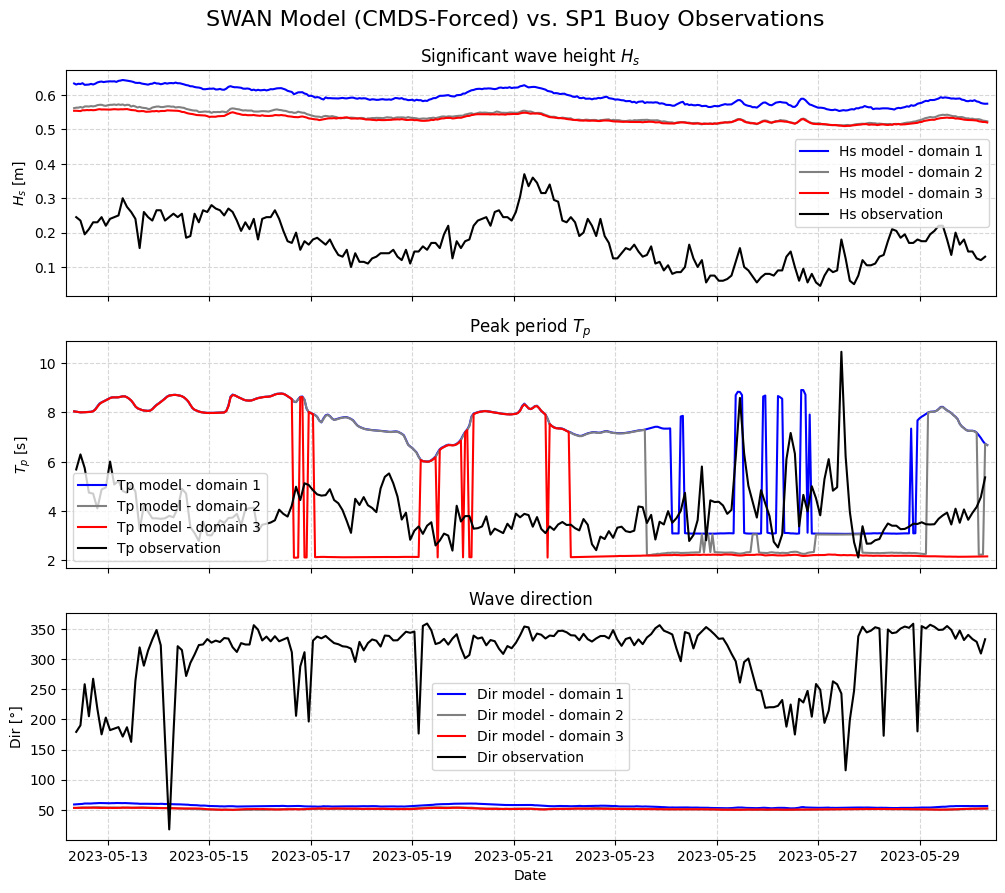

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("SWAN Model (CMDS-Forced) vs. SP1 Buoy Observations", fontsize=16, y=0.94)

# Definir los datos por variable
variables = [
    ('Hs', r'$H_{s}$ [m]', 'Significant wave height $H_{s}$', 'Hs[m]', dict_data_hs1, dict_data_hs2, dict_data_hs3),
    ('Tp', r'$T_{p}$ [s]', 'Peak period $T_{p}$', 'Tp[s]', dict_data_tp1, dict_data_tp2, dict_data_tp3),
    ('Dir', r'Dir [°]', 'Wave direction', 'Dir[°]', dict_data_dir1, dict_data_dir2, dict_data_dir3)
]

times = [time1, time2, time3]
colors = ['blue', 'grey', 'r']
labels = ['model - domain 1', 'model - domain 2', 'model - domain 3']
start_date = datetime(2023,5,12,4,0,0)
end_date = datetime(2023,5,30,12,0,0) - timedelta(minutes=1)

for ax, (varname, ylabel, title, obs_col, d1, d2, d3) in zip(axes, variables):
    for time, color, label, data in zip(times, colors, labels, [d1, d2, d3]):
        ax.plot(time, data[2], color=color, label=f'{varname} {label}')
    
    ax.plot(df_SP1_buoy['date'], df_SP1_buoy[obs_col], color='k', label=f'{varname} observation')
    ax.set(title=title, ylabel=ylabel, xlim=(start_date, end_date))
    ax.legend()
    ax.grid(alpha=0.5, ls='--')

axes[-1].set_xlabel('Date')
plt.show()

# SP2 buoy vs SWAN ERA5-Forced/CMDS-Forced - domain3

## Reading SWAN data

In [25]:
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")
path_case_CMDS = Path("/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_CMDS/run")
path_case_ERA5 = Path("/scratchsan/medellin/ffayalac/runs/swan_SA/May2023_ERA5/run")
reader_CMDS = SwanOutputReader(hs_col="Hsig", tp_col="TPsmoo", dir_col="Dir", n_points=2)
reader_ERA5 = SwanOutputReader(hs_col="Hsig", tp_col="TPsmoo", dir_col="Dir", n_points=2)

time_series_sims3_CMDS, time3_CMDS = reader_CMDS.load_domain(path_case_CMDS / "domain_03", start_datetime, end_datetime)
dict_data_hs3_CMDS = time_series_sims3_CMDS['hs']
dict_data_tp3_CMDS = time_series_sims3_CMDS['tp']
dict_data_dir3_CMDS = time_series_sims3_CMDS['dir']

time_series_sims3_ERA5, time3_ERA5 = reader_ERA5.load_domain(path_case_ERA5 / "domain_03", start_datetime, end_datetime)
dict_data_hs3_ERA5 = time_series_sims3_ERA5['hs']
dict_data_tp3_ERA5 = time_series_sims3_ERA5['tp']
dict_data_dir3_ERA5 = time_series_sims3_ERA5['dir']


## Reading field data

In [26]:
file_path = r'/scratchsan/medellin/lroserom/working_folder/data/processed/may2023/Out_Reef/buoy_outreef_may2023.csv'


# Read CSV with the first row as column headers
df_SP2_buoy = pd.read_csv(file_path, header=0)
df_SP2_buoy["date"] = pd.to_datetime(df_SP2_buoy["date"])
start_datetime = pd.Timestamp("2023-05-12 08:00:00")
end_datetime   = pd.Timestamp("2023-05-30 08:00:00")


df_SP2_buoy = df_SP2_buoy.loc[
    (df_SP2_buoy["date"] >= start_datetime) &
    (df_SP2_buoy["date"] <= end_datetime)
]

df_SP2_buoy

,date,Hs[m],Tp[s],Dir[°]
260,2023-05-12 08:00:00,1.76,5.84,56.566
261,2023-05-12 09:00:00,1.84,5.82,59.371
262,2023-05-12 10:00:00,2.83,9.20,65.154
263,2023-05-12 11:00:00,1.94,5.92,64.186
264,2023-05-12 12:00:00,1.86,5.46,66.251
...,...,...,...,...
670,2023-05-30 04:00:00,0.81,5.30,80.441
671,2023-05-30 05:00:00,0.82,5.30,82.552
672,2023-05-30 06:00:00,0.78,5.36,82.811
673,2023-05-30 07:00:00,0.81,5.60,81.111


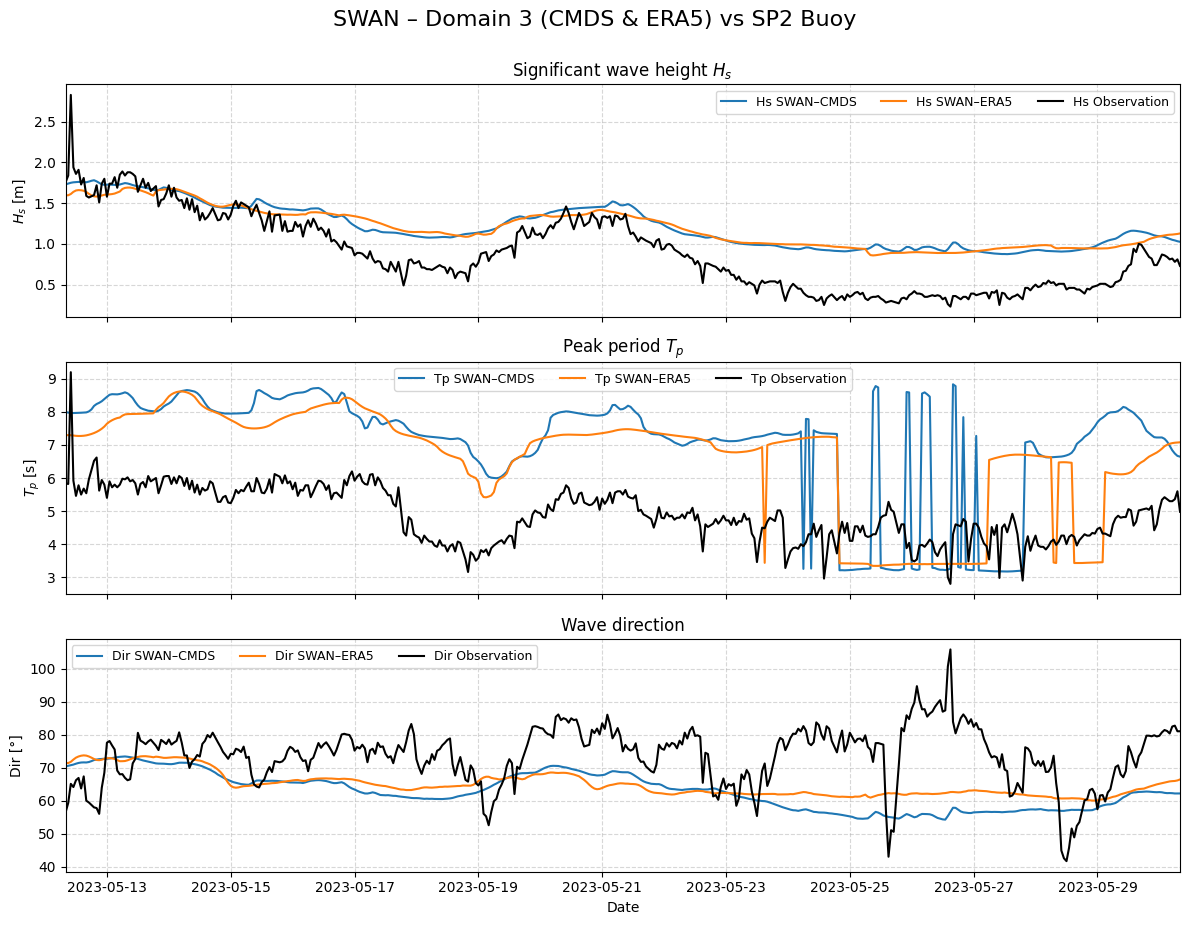

In [30]:
point_idx = 1 
df_buoy = df_SP2_buoy 

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("SWAN – Domain 3 (CMDS & ERA5) vs SP2 Buoy", fontsize=16, y=0.92)

# (nombre, ylabel, título, columna_obs, (tiempo_CMDS, dict_CMDS), (tiempo_ERA5, dict_ERA5))
variables = [
    ('Hs', r'$H_{s}$ [m]', 'Significant wave height $H_{s}$', 'Hs[m]',
     (time3_CMDS, dict_data_hs3_CMDS),
     (time3_ERA5, dict_data_hs3_ERA5)),
    ('Tp', r'$T_{p}$ [s]', 'Peak period $T_{p}$', 'Tp[s]',
     (time3_CMDS, dict_data_tp3_CMDS),
     (time3_ERA5, dict_data_tp3_ERA5)),
    ('Dir', r'Dir [°]', 'Wave direction', 'Dir[°]',
     (time3_CMDS, dict_data_dir3_CMDS),
     (time3_ERA5, dict_data_dir3_ERA5)),
]

for ax, (varname, ylabel, title, obs_col, (t_cmds, d_cmds), (t_era5, d_era5)) in zip(axes, variables):
    # SWAN forzado con CMDS
    ax.plot(t_cmds, d_cmds[point_idx], color='tab:blue', label=f'{varname} SWAN–CMDS')
    # SWAN forzado con ERA5
    ax.plot(t_era5, d_era5[point_idx], color='tab:orange', label=f'{varname} SWAN–ERA5')
    # Observación
    ax.plot(df_buoy['date'], df_buoy[obs_col], color='k', label=f'{varname} Observation')

    ax.set(title=title, ylabel=ylabel, xlim=(start_datetime, end_datetime))
    ax.grid(alpha=0.5, ls='--')
    ax.legend(ncol=3, fontsize=9)

axes[-1].set_xlabel('Date')
plt.tight_layout(rect=[0, 0, 1, 0.92])  # deja espacio para el suptitle
plt.show()
